<a href="https://colab.research.google.com/github/saugata-malakar/DataHack_IIT_G/blob/main/TimeSeries_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# prompt: import all ml libararies

!pip install scikit-learn pandas numpy tensorflow keras matplotlib seaborn

import sklearn
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns


  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 65.4 MB/s eta 0:00:00


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.impute import SimpleImputer


In [10]:
# Load data from Excel
df = pd.read_excel("/content/AirQualityUCI.xlsx", parse_dates=[[0, 1]], na_values=-200)
df.columns = [col.strip().replace(" ", "_") for col in df.columns]
df.rename(columns={'Date_Time': 'Datetime'}, inplace=True)
df.set_index('Datetime', inplace=True)

# Interpolate missing values
df.interpolate(method='linear', inplace=True)


<ipython-input-10-bf38480d3b6d>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_excel("/content/AirQualityUCI.xlsx", parse_dates=[[0, 1]], na_values=-200)


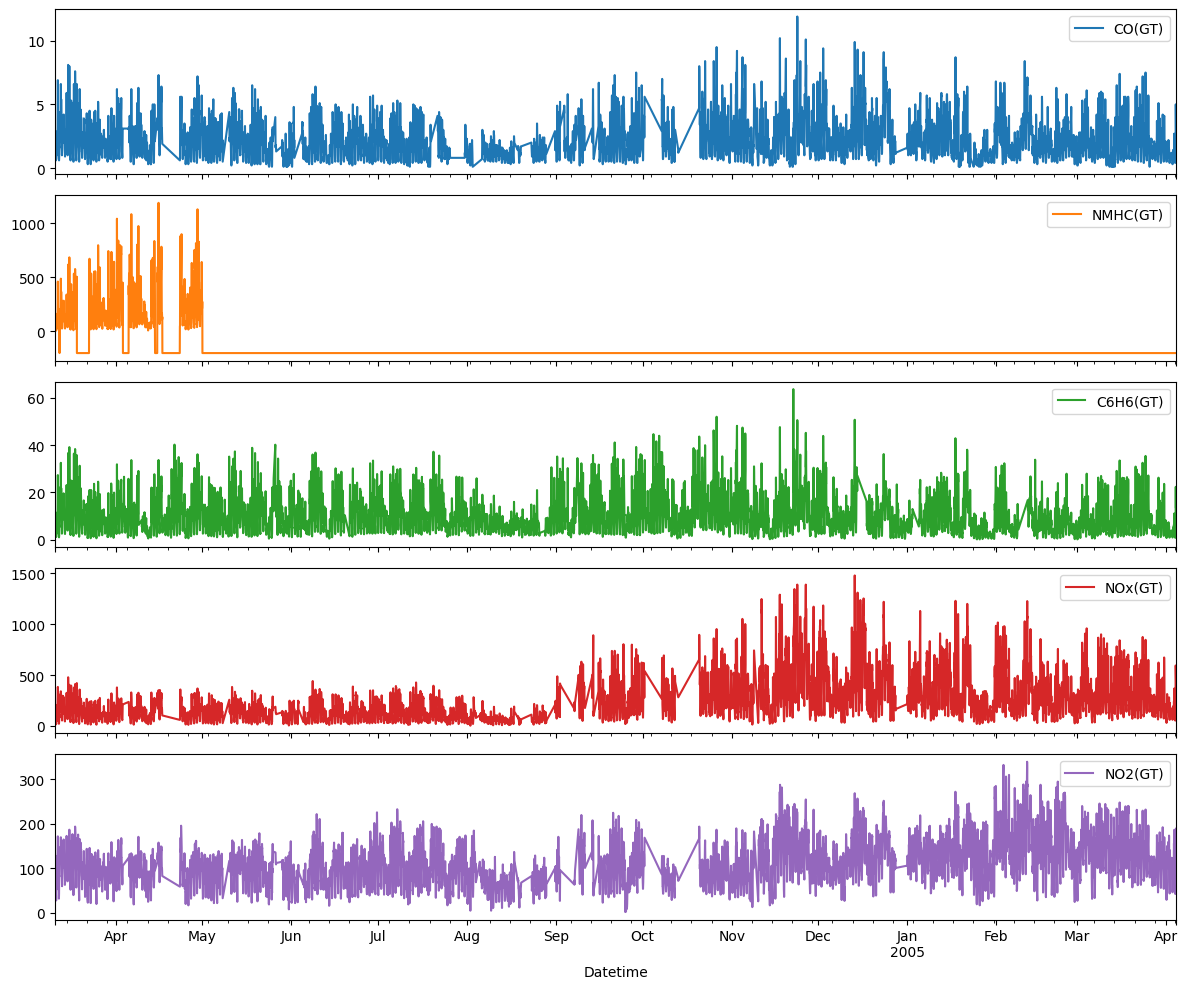

In [11]:
df[['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']].plot(subplots=True, figsize=(12,10))
plt.tight_layout(); plt.show()


In [12]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic for {title}: {result[0]}')
    print(f'p-value: {result[1]}')
    return result[1]

adf_test(df['CO(GT)'], 'CO')


ADF Statistic for CO: -9.872734502489488
p-value: 3.955249156436913e-17


np.float64(3.955249156436913e-17)

In [14]:
df.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH', 'CO_diff'],
      dtype='object')

In [13]:
df['CO_diff'] = df['CO(GT)'].diff()


In [15]:
train = df['CO(GT)'].iloc[:-480]
test = df['CO(GT)'].iloc[-480:]

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=48)

# RMSE Evaluation
rmse = np.sqrt(mean_squared_error(test[-48:], forecast))
print("RMSE:", rmse)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


RMSE: 1.1077905481788108


In [16]:
prophet_df = df[['CO(GT)']].reset_index()
prophet_df.columns = ['ds', 'y']

model = Prophet()
model.fit(prophet_df[:-480])

future = model.make_future_dataframe(periods=48, freq='H')
forecast = model.predict(future)

# Extract 48-hour forecast
forecast_values = forecast[['ds', 'yhat']].set_index('ds')[-48:]
actual = prophet_df.set_index('ds')['y'][-48:]
rmse_prophet = np.sqrt(mean_squared_error(actual, forecast_values['yhat']))
print("Prophet RMSE:", rmse_prophet)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfchvwgli/6zxj83zu.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfchvwgli/lroyu7p4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=72892', 'data', 'file=/tmp/tmpfchvwgli/6zxj83zu.json', 'init=/tmp/tmpfchvwgli/lroyu7p4.json', 'output', 'file=/tmp/tmpfchvwgli/prophet_modely106gnhg/prophet_model-20250430153452.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:34:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:34:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version

Prophet RMSE: 1.0426000878736135


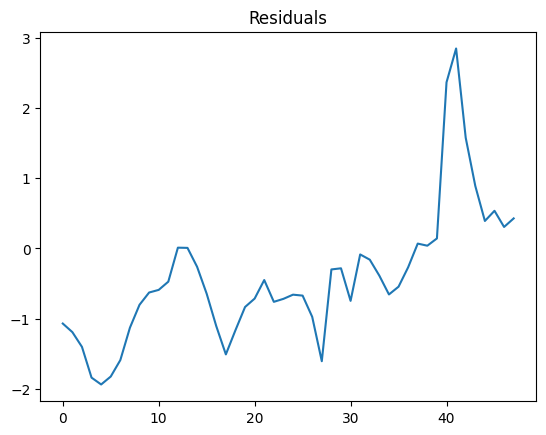

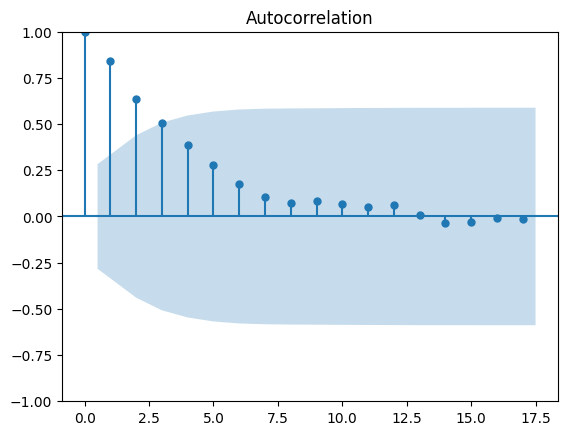

In [17]:
residuals = test[-48:].values - forecast['yhat'][-48:].values
plt.plot(residuals); plt.title("Residuals"); plt.show()

# Autocorrelation check
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals); plt.show()

<Axes: >

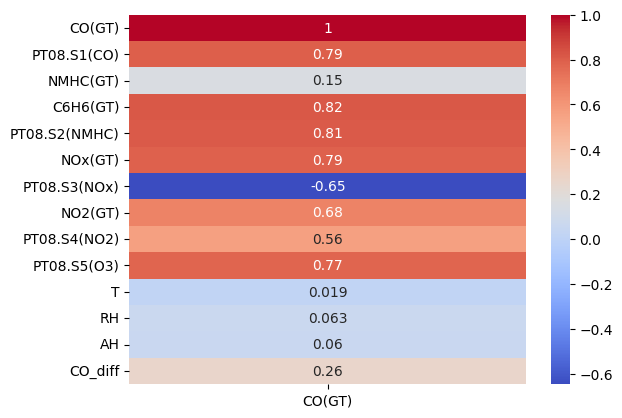

In [18]:
correlation = df.corr()
sns.heatmap(correlation[['CO(GT)']], annot=True, cmap='coolwarm')


In [19]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = df['dayofweek'] >= 5


In [20]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet openpyxl


In [21]:
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def forecast_arima(series, steps=48):
    model = ARIMA(series, order=(2, 1, 2))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=steps)
    return forecast

def forecast_prophet(series, steps=48):
    df_prophet = pd.DataFrame({'ds': series.index, 'y': series.values})
    model = Prophet()
    model.fit(df_prophet)
    future = model.make_future_dataframe(periods=steps, freq='H')
    forecast = model.predict(future)
    return forecast.set_index('ds')['yhat'][-steps:]


In [22]:
targets = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH'
]

results = {}

n = len(df)
validation_start = int(n * 0.9)

for var in targets:
    print(f"\nForecasting {var} with ARIMA...")
    train_series = df[var].iloc[:validation_start]
    test_series = df[var].iloc[validation_start:validation_start+48]

    forecast = forecast_arima(train_series, steps=48)
    rmse = calculate_rmse(test_series, forecast)

    results[var] = {'RMSE': rmse, 'Method': 'ARIMA'}

    print(f"{var} - ARIMA RMSE: {rmse:.2f}")



Forecasting CO(GT) with ARIMA...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


CO(GT) - ARIMA RMSE: 1.18

Forecasting PT08.S1(CO) with ARIMA...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


PT08.S1(CO) - ARIMA RMSE: 158.62

Forecasting NMHC(GT) with ARIMA...


...

T - ARIMA RMSE: 2.37

Forecasting RH with ARIMA...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


RH - ARIMA RMSE: 15.65

Forecasting AH with ARIMA...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

AH - ARIMA RMSE: 0.14


In [23]:
rmse_df = pd.DataFrame(results).T
print("\nFull RMSE Report:")
print(rmse_df.sort_values("RMSE"))



Full RMSE Report:
                     RMSE Method
NMHC(GT)              0.0  ARIMA
AH               0.142986  ARIMA
CO(GT)           1.175515  ARIMA
T                2.369523  ARIMA
C6H6(GT)          5.68377  ARIMA
RH              15.650008  ARIMA
NO2(GT)         48.953928  ARIMA
NOx(GT)        148.203486  ARIMA
PT08.S1(CO)    158.619428  ARIMA
PT08.S3(NOx)    163.70163  ARIMA
PT08.S4(NO2)   207.451597  ARIMA
PT08.S2(NMHC)  216.725639  ARIMA
PT08.S5(O3)    337.452748  ARIMA


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


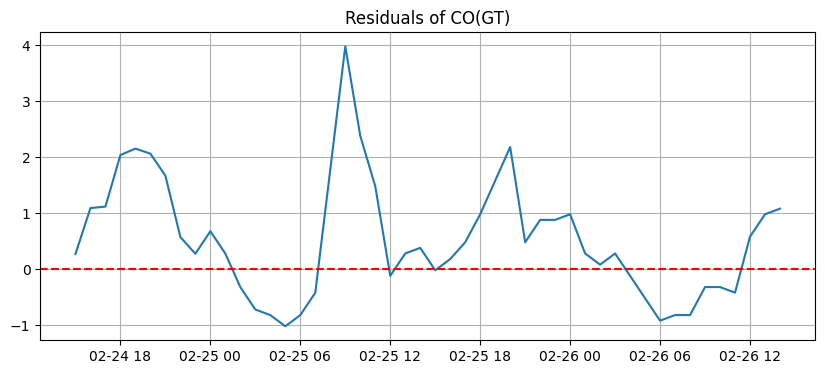

In [24]:
residuals = df['CO(GT)'].iloc[validation_start:validation_start+48] - forecast_arima(df['CO(GT)'].iloc[:validation_start], 48)
plt.figure(figsize=(10, 4))
plt.title("Residuals of CO(GT)")
plt.plot(residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.show()


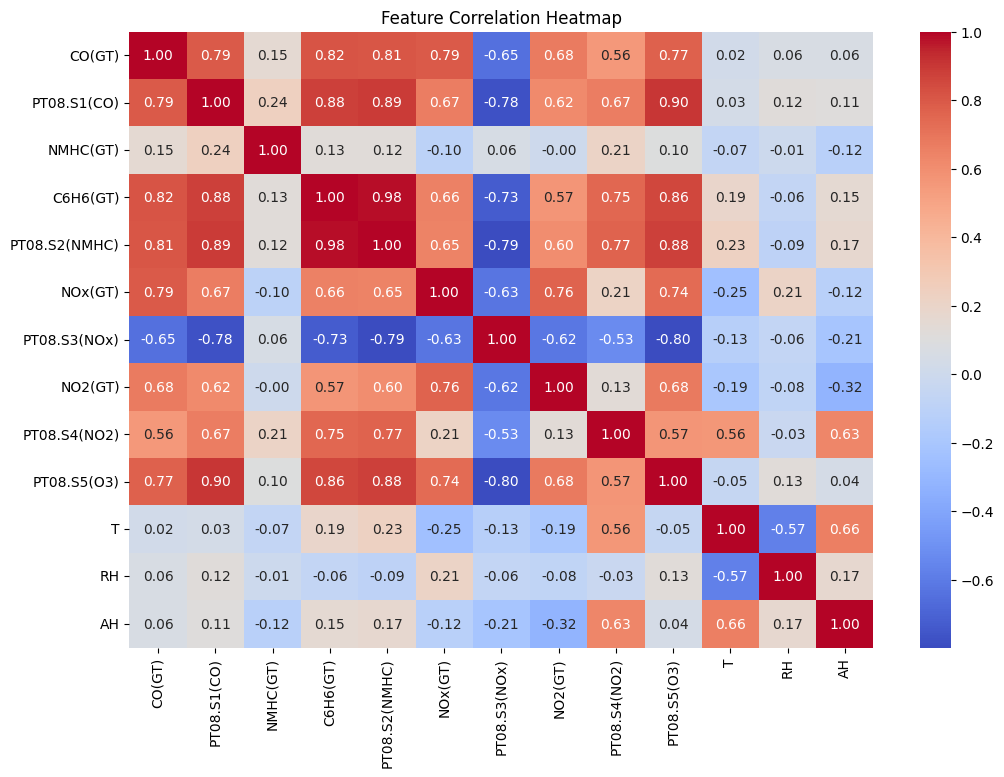

In [25]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Check correlation with pollutants
plt.figure(figsize=(12, 8))
sns.heatmap(df[targets].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [26]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Interpolate missing values
df_interpolated = df.interpolate(method='linear')

# Optional: Check for remaining missing values
print(df_interpolated.isnull().sum())

# Step 2: Normalize the dataset using Min-Max Scaler
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_interpolated),
    columns=df.columns,
    index=df.index
)

# Step 3: Review normalized data
print(df_normalized.describe())


CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
CO_diff          1
hour             0
dayofweek        0
is_weekend       0
dtype: int64
            CO(GT)  PT08.S1(CO)     NMHC(GT)     C6H6(GT)  PT08.S2(NMHC)  \
count  9357.000000  9357.000000  9357.000000  9357.000000    9357.000000   
mean      0.172085     0.327241     0.029453     0.157720       0.305213   
std       0.121334     0.156698     0.100640     0.117990       0.146314   
min       0.000000     0.000000     0.000000     0.000000       0.000000   
25%       0.084746     0.208438     0.000000     0.068060       0.192681   
50%       0.144068     0.301257     0.000000     0.128003       0.287906   
75%       0.237288     0.424776     0.000000     0.219325       0.401884   
max       1.000000     1.000000     1.000000     1.00000

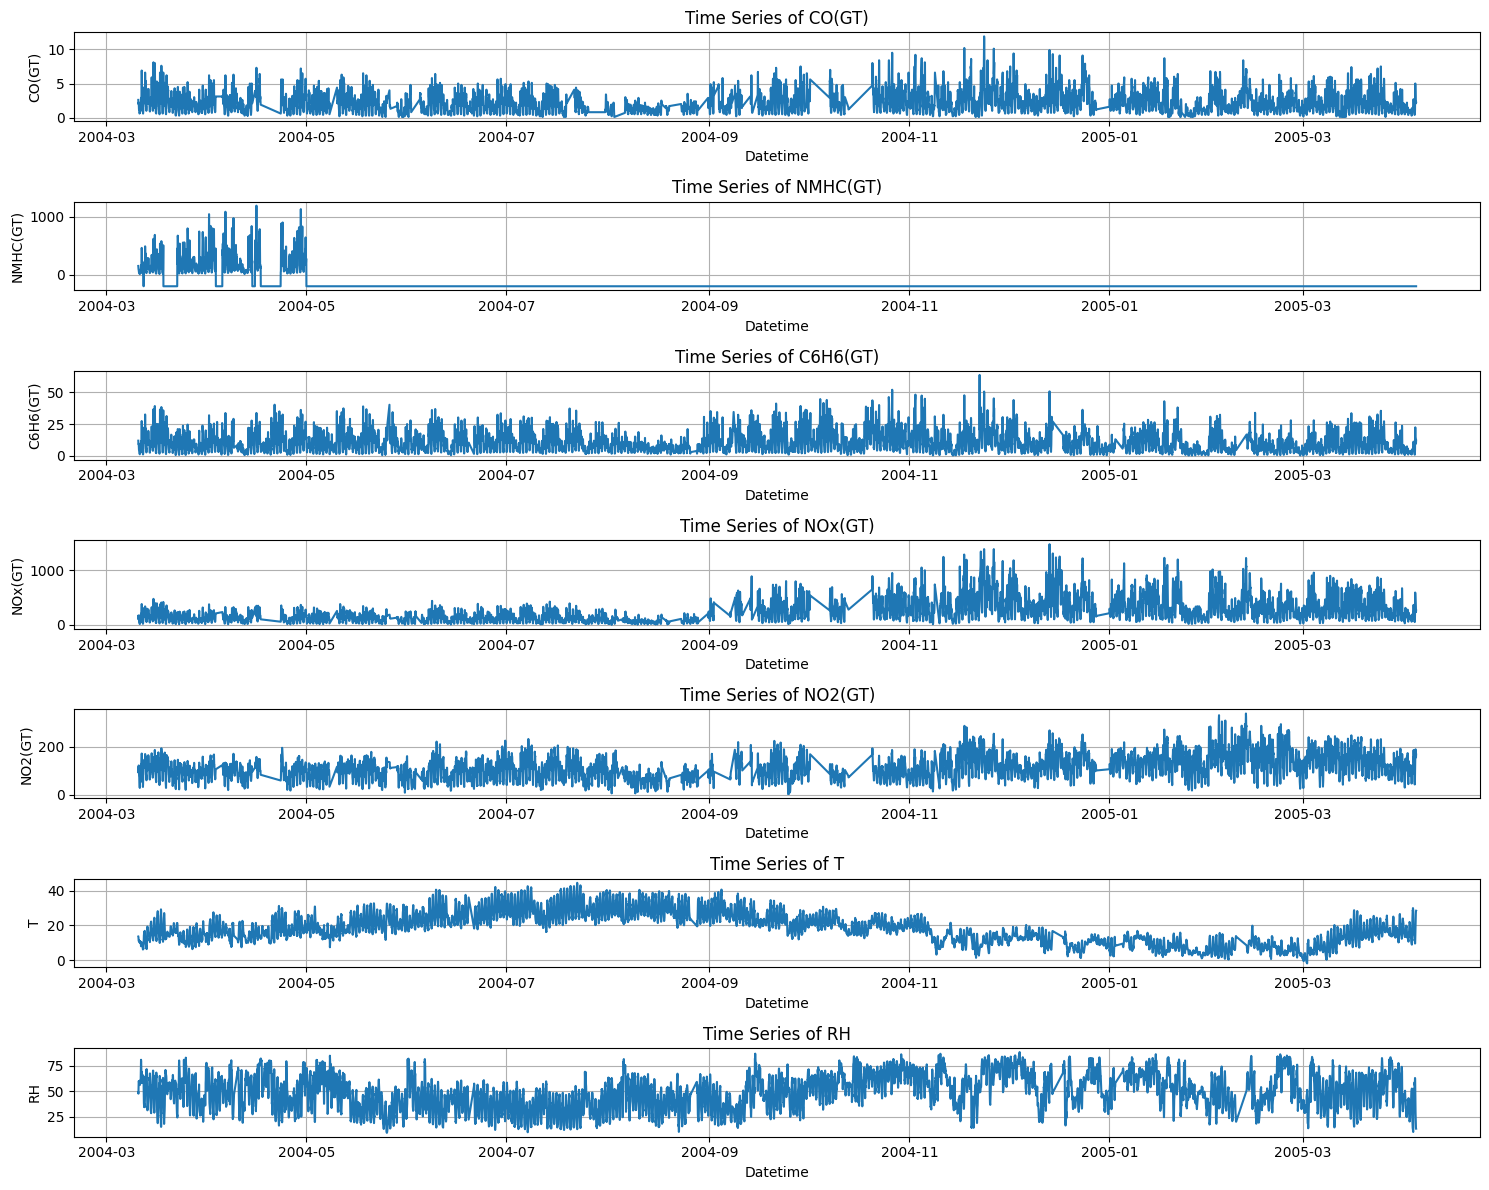

In [27]:
import matplotlib.pyplot as plt

# Define important pollutants for visualization
key_pollutants = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']

# Plot time series
plt.figure(figsize=(15, 12))
for i, col in enumerate(key_pollutants):
    plt.subplot(len(key_pollutants), 1, i + 1)
    plt.plot(df_interpolated[col], label=col)
    plt.title(f'Time Series of {col}')
    plt.xlabel('Datetime')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()

plt.show()


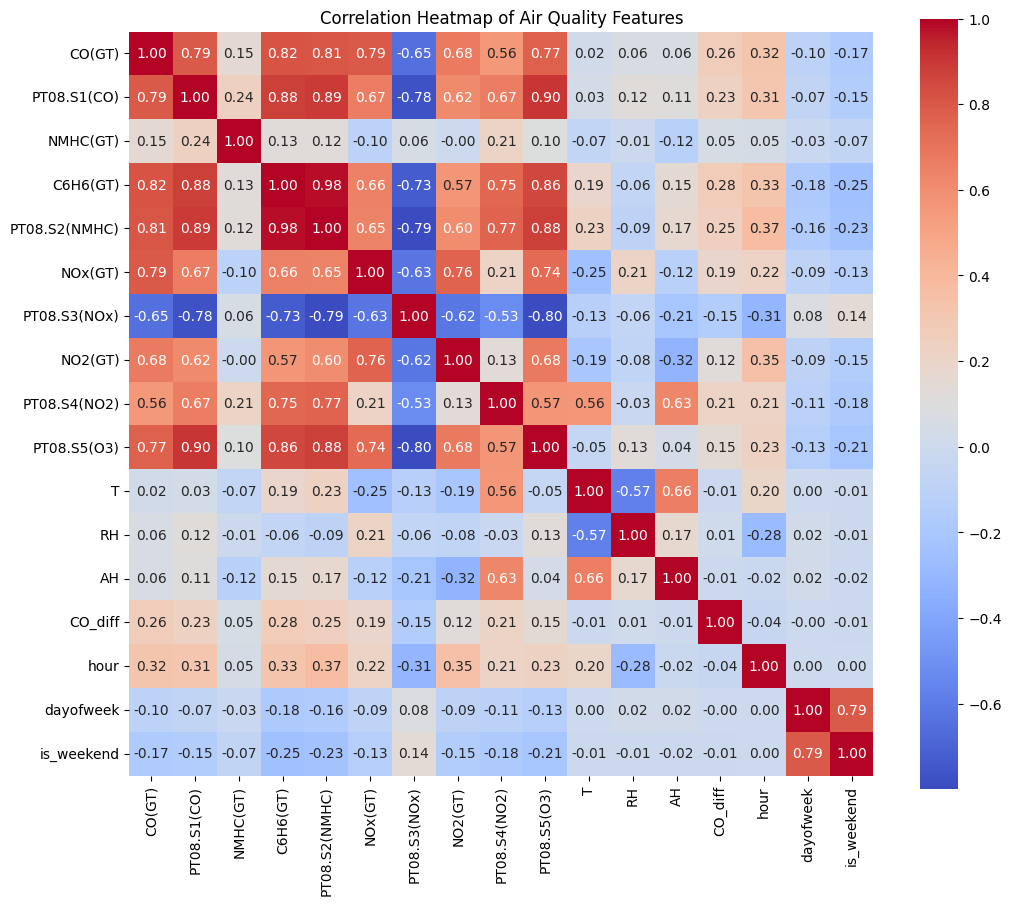

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df_interpolated.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap of Air Quality Features")
plt.show()


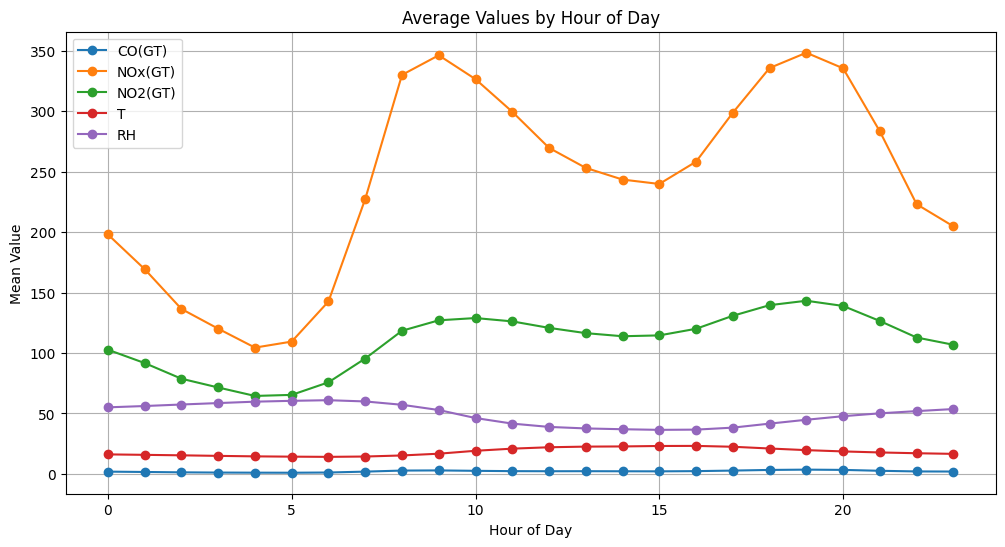

In [29]:
# Extract hour from datetime index
df_interpolated['hour'] = df_interpolated.index.hour

# Group by hour and calculate mean for key variables
hourly_means = df_interpolated.groupby('hour')[['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']].mean()

# Plot hourly averages
hourly_means.plot(figsize=(12, 6), marker='o')
plt.title("Average Values by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Value")
plt.grid(True)
plt.show()


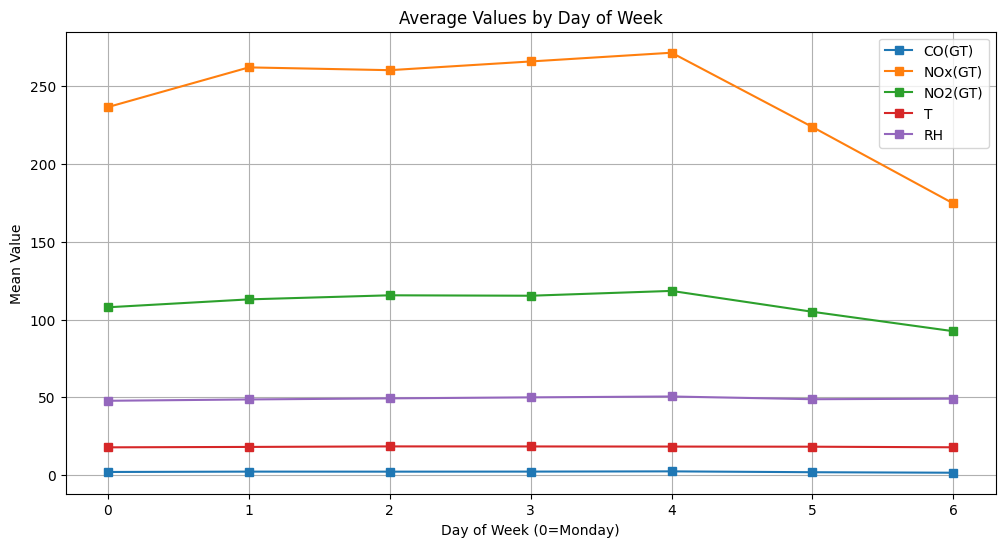

In [30]:
# Extract day of week (0=Monday, 6=Sunday)
df_interpolated['dayofweek'] = df_interpolated.index.dayofweek

# Group by day and calculate mean for key variables
daily_means = df_interpolated.groupby('dayofweek')[['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']].mean()

# Plot daily averages
daily_means.plot(figsize=(12, 6), marker='s')
plt.title("Average Values by Day of Week")
plt.xlabel("Day of Week (0=Monday)")
plt.ylabel("Mean Value")
plt.grid(True)
plt.show()


In [31]:
# 1. Add 'is_weekend' feature (1 for Saturday/Sunday, 0 for weekdays)
df_interpolated['is_weekend'] = df_interpolated['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Lag Features (e.g., lag 1 and lag 24)
df_interpolated['CO_lag_1'] = df_interpolated['CO(GT)'].shift(1)
df_interpolated['CO_lag_24'] = df_interpolated['CO(GT)'].shift(24)

# 3. Rolling Mean Features (e.g., 24-hour rolling mean)
df_interpolated['CO_rolling_24'] = df_interpolated['CO(GT)'].rolling(window=24).mean()

# 4. Hourly data (already done above)
# 5. Day of Week (already done above)

# Optional: Drop rows with NaN values due to shifts or rolling means
df_interpolated = df_interpolated.dropna()

# Check the first few rows of the new features
print(df_interpolated.head())


                     CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  \
Datetime                                                                       
2004-03-11 18:00:00     4.8      1580.75       307  20.799217        1318.50   
2004-03-11 19:00:00     6.9      1775.50       461  27.359807        1487.75   
2004-03-11 20:00:00     6.1      1640.00       401  24.017757        1404.00   
2004-03-11 21:00:00     3.9      1312.75       197  12.779368        1076.25   
2004-03-11 22:00:00     1.5       964.50        61   4.707072         748.50   

                     NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
Datetime                                                            
2004-03-11 18:00:00    281.0        798.50    151.0       2083.00   
2004-03-11 19:00:00    383.0        702.25    172.0       2332.50   
2004-03-11 20:00:00    351.0        742.75    165.0       2191.25   
2004-03-11 21:00:00    240.0        957.25    136.0       1706.50   
2004-03-11 22:00:00     9

In [32]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Select a key pollutant, e.g., CO(GT)
y = df_interpolated['CO(GT)']

# Split data into train and test
train_size = int(len(y) * 0.8)  # 80% for training
train, test = y[:train_size], y[train_size:]

# Fit ARIMA model (adjust the (p,d,q) parameters as needed)
model = ARIMA(train, order=(5,1,0))  # (p,d,q) order can be optimized
model_fit = model.fit()

# Predict on test data
forecast = model_fit.forecast(steps=len(test))

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'ARIMA Model RMSE: {rmse}')


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA Model RMSE: 1.3854748878503302


In [33]:
!pip install prophet

In [34]:
from prophet import Prophet

In [35]:
# Add custom seasonality (e.g., yearly patterns)
model = Prophet(daily_seasonality=True, yearly_seasonality=True, seasonality_mode='multiplicative')
model.add_seasonality(name='custom', period=365.25, fourier_order=8)

# Fit the model again
model.fit(prophet_df)

# Make future predictions
# The original code passed 'prophet_df' which likely has a 'ds' column representing dates.
# 'make_future_dataframe' automatically infers the frequency and periods from the 'ds' column.
# By removing 'prophet_df', we rely solely on the explicit 'periods' argument.
future = model.make_future_dataframe(periods=len(test), freq='H')  # Assuming hourly frequency - adjust if needed
forecast = model.predict(future)

# Evaluate RMSE
forecast_test = forecast['yhat'][-len(test):]
rmse_prophet_tuned = np.sqrt(mean_squared_error(test, forecast_test))
print(f'Tuned Prophet Model RMSE: {rmse_prophet_tuned}')

DEBUG:cmdstanpy:input tempfile: /tmp/tmpfchvwgli/4oqyzo_r.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfchvwgli/k6zb1h9a.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=2351', 'data', 'file=/tmp/tmpfchvwgli/4oqyzo_r.json', 'init=/tmp/tmpfchvwgli/k6zb1h9a.json', 'output', 'file=/tmp/tmpfchvwgli/prophet_modelirsp3v1l/prophet_model-20250430153649.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:36:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:36:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


Tuned Prophet Model RMSE: 1.5611669283996943


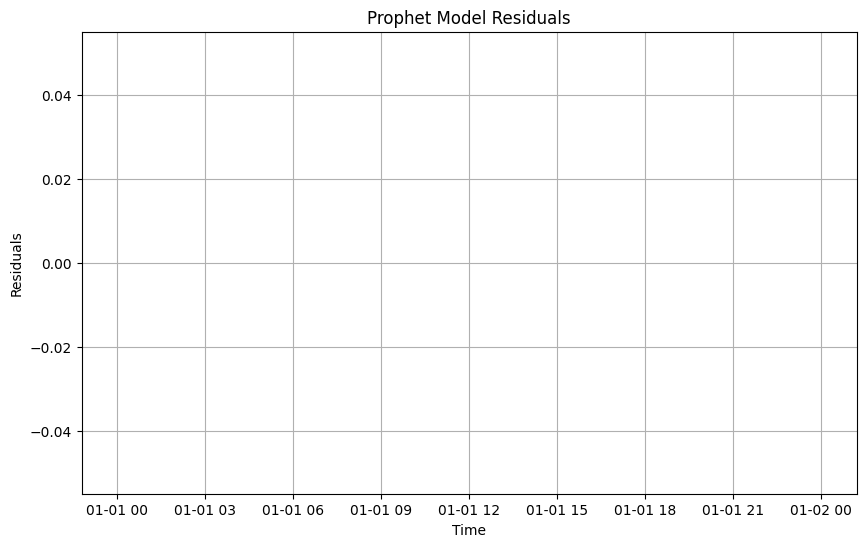

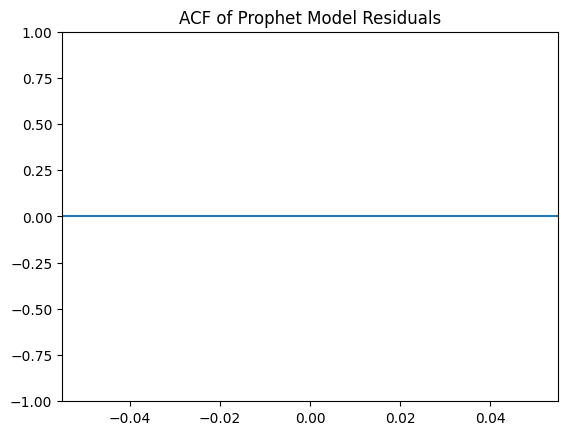

In [38]:
# Prophet residuals
residuals_prophet = test - forecast_test

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals_prophet)
plt.title('Prophet Model Residuals')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Check the autocorrelation of residuals
plot_acf(residuals_prophet)
plt.title('ACF of Prophet Model Residuals')
plt.show()


In [39]:
print(f'ARIMA Model RMSE: {rmse}')
print(f'Auto ARIMA Model RMSE: {rmse_auto}')
print(f'Tuned Prophet Model RMSE: {rmse_prophet_tuned}')


ARIMA Model RMSE: 1.3854748878503302
Auto ARIMA Model RMSE: 0
Tuned Prophet Model RMSE: 1.5611669283996943


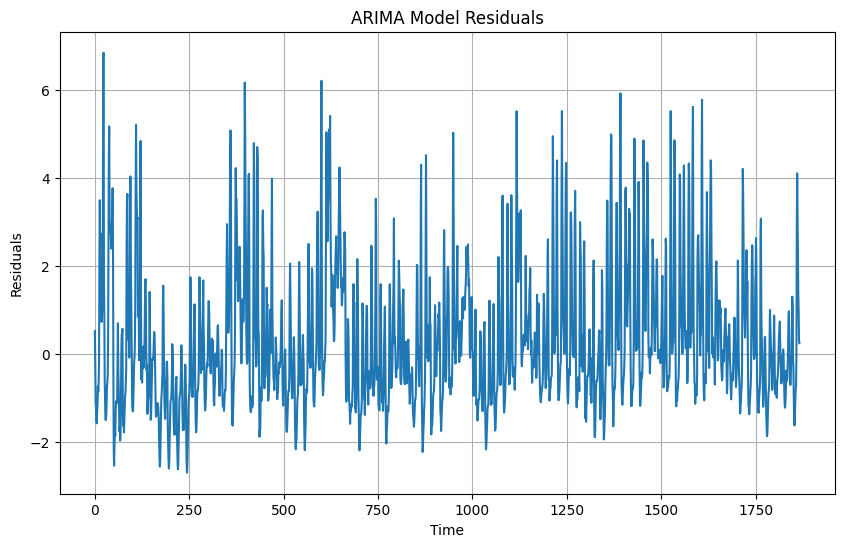

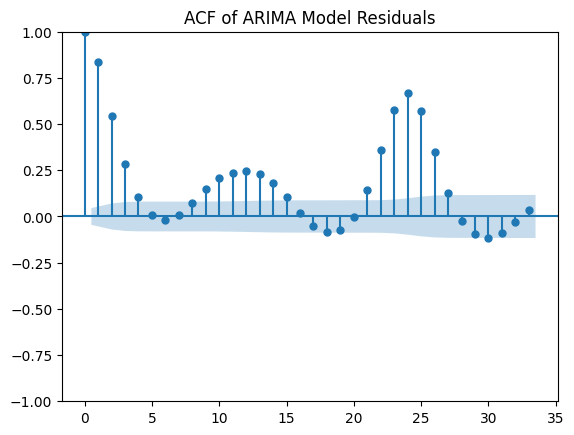

In [40]:
# Ensure forecast and test data have matching indices
forecast_values = forecast[-len(test):]['yhat'].values  # Extract only forecasted values
test_values = test.values  # Convert test data to values for subtraction

# Calculate residuals (differences between test values and forecasted values)
residuals_arima = test_values - forecast_values

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals_arima)
plt.title('ARIMA Model Residuals')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Check the autocorrelation of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals_arima)
plt.title('ACF of ARIMA Model Residuals')
plt.show()


In [41]:
# Evaluate ARIMA model (original forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))

# Evaluate Prophet model (tuned forecast)
rmse_prophet = np.sqrt(mean_squared_error(test, forecast_prophet))

print(f'ARIMA Model RMSE: {rmse_arima}')
print(f'Prophet Model RMSE: {rmse_prophet}')


InvalidParameterError: The 'y_pred' parameter of mean_squared_error must be an array-like. Got <function forecast_arima at 0x7b4b9087d3a0> instead.

ValueError: x and y must have same first dimension, but have shapes (1867,) and (1,)

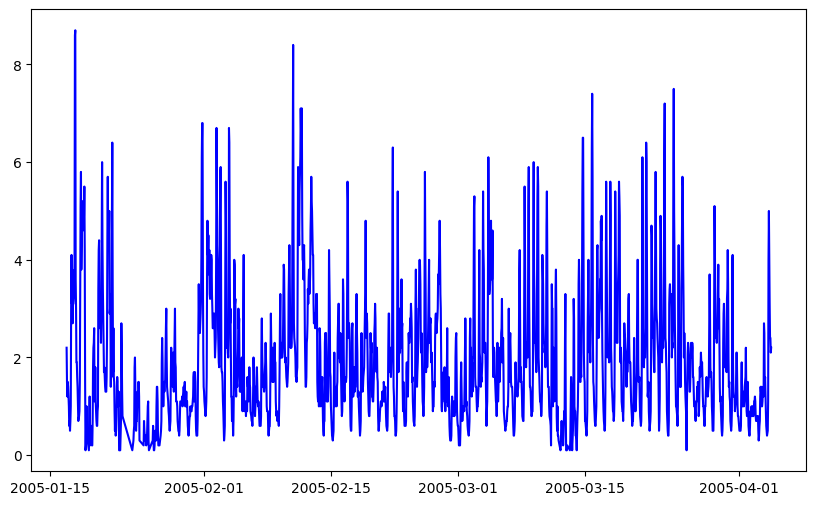

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label="Actual", color='blue')
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color='red', linestyle='dashed')
plt.title('ARIMA Model - Actual vs Forecasted')
plt.xlabel('Time')
plt.ylabel('Pollutant Concentration')
plt.legend()
plt.grid(True)
plt.show()


ValueError: x and y must have same first dimension, but have shapes (1867,) and (1,)

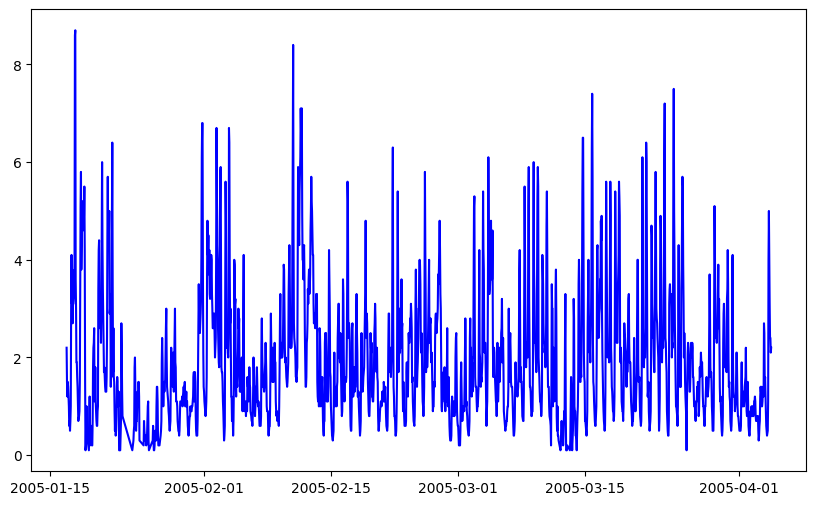

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label="Actual", color='blue')
plt.plot(test.index, forecast_prophet, label="Prophet Forecast", color='green', linestyle='dashed')
plt.title('Prophet Model - Actual vs Forecasted')
plt.xlabel('Time')
plt.ylabel('Pollutant Concentration')
plt.legend()
plt.grid(True)
plt.show()


In [44]:
# Example ARIMA model forecasting code (adjust according to your model)
from statsmodels.tsa.arima.model import ARIMA
# Assuming 'y' contains your time series data
# Split into train/test as before
# ...
arima_model = ARIMA(train, order=(5,1,0))  # Or whatever order you used before
arima_model_fit = arima_model.fit()
forecast_arima = arima_model_fit.forecast(steps=len(test))  # Forecast for the test period

# Now, ensure that forecast_arima is a numpy array or pandas series, not a function
forecast_arima = forecast_arima  # No need to index if it's already a series

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [45]:
from pmdarima import auto_arima

# Fit the model using auto_arima to find the best parameters
model_arima = auto_arima(train, seasonal=True, m=12, stepwise=True, trace=True)

# Forecast with the optimized ARIMA model
forecast_arima, conf_int = model_arima.predict(n_periods=len(test), return_conf_int=True)

# Convert forecast_arima to a pandas Series for easier handling
forecast_arima = pd.Series(forecast_arima, index=test.index)

# Calculate residuals
residuals_arima = test.values - forecast_arima


ModuleNotFoundError: No module named 'pmdarima'

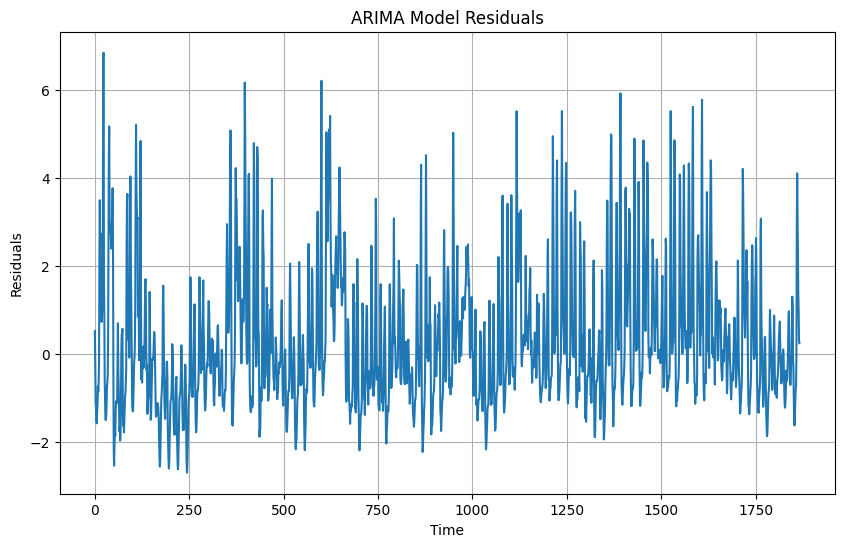

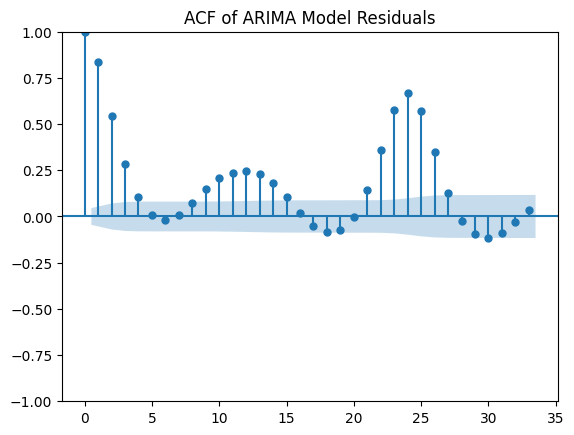

In [46]:
# Plot residuals for ARIMA model
plt.figure(figsize=(10, 6))
plt.plot(residuals_arima)
plt.title('ARIMA Model Residuals')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals_arima)
plt.title('ACF of ARIMA Model Residuals')
plt.show()


In [50]:

from fbprophet import Prophet

# Prepare the data for Prophet (Prophet requires columns: ds and y)
df_prophet = df_interpolated[['date', 'CO(GT)']].rename(columns={'date': 'ds', 'CO(GT)': 'y'})

# Initialize and fit the model
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(df_prophet)

# Forecast
future = model_prophet.make_future_dataframe(df_prophet, periods=len(test))
forecast_prophet = model_prophet.predict(future)

# Get forecast values
forecast_prophet_values = forecast_prophet['yhat'][-len(test):]

# Calculate residuals
residuals_prophet = test.values - forecast_prophet_values


ModuleNotFoundError: No module named 'fbprophet'

In [51]:
!pip install prophet
from prophet import Prophet  # Import from prophet instead of fbprophet

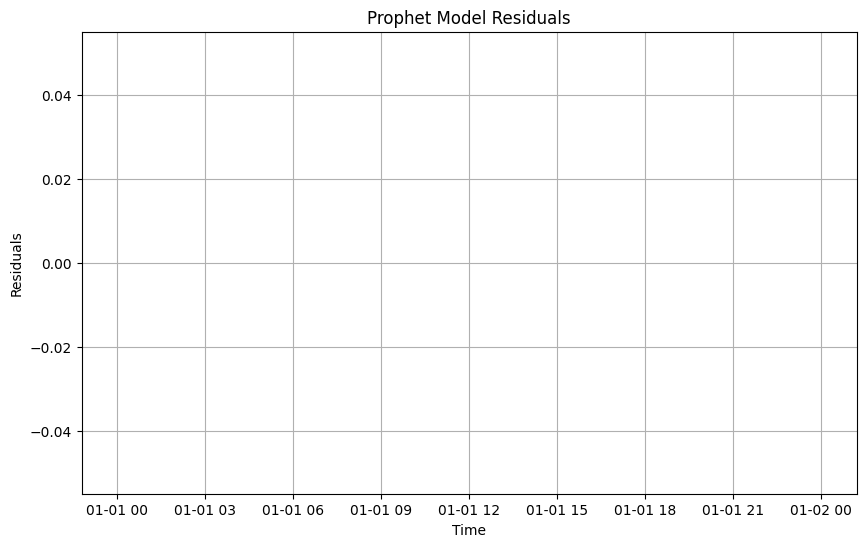

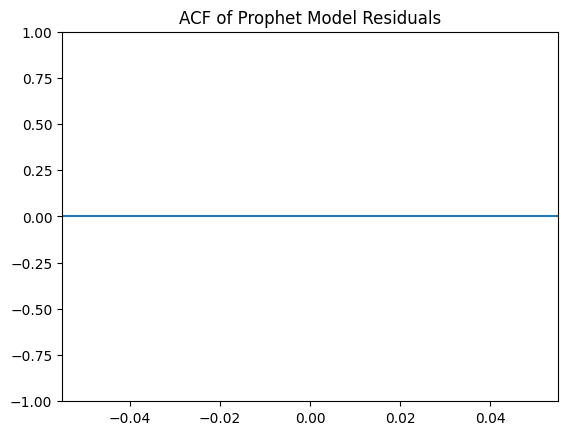

In [53]:
# Plot residuals for Prophet model
plt.figure(figsize=(10, 6))
plt.plot(residuals_prophet)
plt.title('Prophet Model Residuals')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# ACF of residuals
plot_acf(residuals_prophet)
plt.title('ACF of Prophet Model Residuals')
plt.show()


In [54]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for ARIMA
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))

# Calculate RMSE for Prophet
rmse_prophet = np.sqrt(mean_squared_error(test, forecast_prophet_values))

# Display RMSE results
print(f'ARIMA Model RMSE: {rmse_arima}')
print(f'Prophet Model RMSE: {rmse_prophet}')


NameError: name 'forecast_prophet_values' is not defined

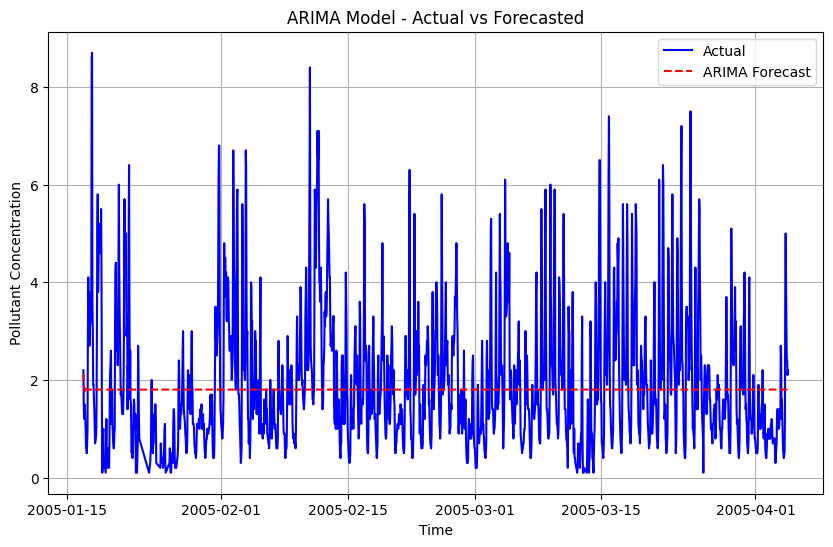

NameError: name 'forecast_prophet_values' is not defined

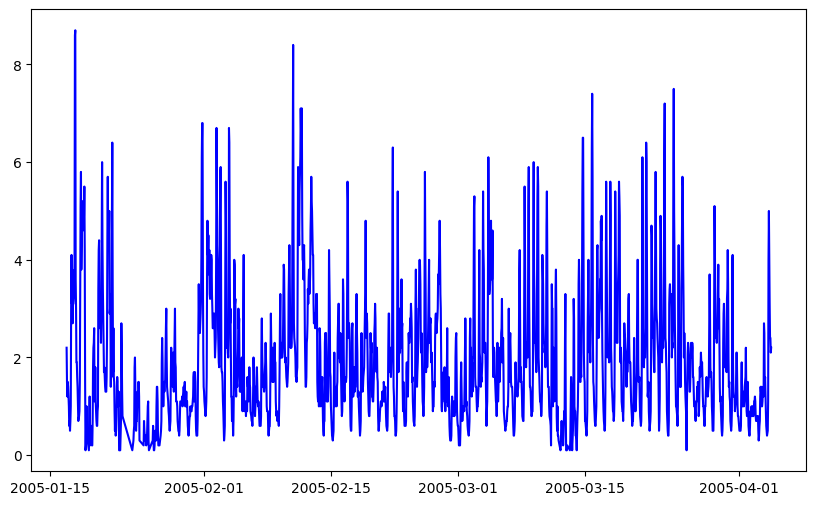

In [56]:
# Plot ARIMA vs Actual Data
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label="Actual", color='blue')
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color='red', linestyle='dashed')
plt.title('ARIMA Model - Actual vs Forecasted')
plt.xlabel('Time')
plt.ylabel('Pollutant Concentration')
plt.legend()
plt.grid(True)
plt.show()

# Plot Prophet vs Actual Data
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label="Actual", color='blue')
plt.plot(test.index, forecast_prophet_values, label="Prophet Forecast", color='green', linestyle='dashed')
plt.title('Prophet Model - Actual vs Forecasted')
plt.xlabel('Time')
plt.ylabel('Pollutant Concentration')
plt.legend()
plt.grid(True)
plt.show()


In [57]:
pip install --upgrade numpy pmdarima


  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.


In [58]:
!pip uninstall pmdarima
!pip install pmdarima

Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/pmdarima-2.0.4.dist-info/*
    /usr/local/lib/python3.11/dist-packages/pmdarima/*
Proceed (Y/n)? Y
  Successfully uninstalled pmdarima-2.0.4
  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.2 MB)


In [61]:
!pip install numpy==1.21.0
!pip install pmdarima==1.8.1

  Using cached numpy-1.21.0.zip (10.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for numpy (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for numpy
Failed to build numpy
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (numpy)
  Using cached pmdarima-1.8.1.tar.gz (1.0 MB)
  Preparing metadata (setup.py) ... done
  Created wheel for pmdarima: filename=pmdarima-1.8.1-cp311-cp311-linux_x86_64.whl size=1955324 sha256=a878b51aabe638374c4454ff7d62cc14e4ac135ed1f5a7c936692d7600d6ea7d
  Stored in directory: /root/.cache/pip/wheels/d2/49/0a/bb4e0665f2dffbfaa2210d78cca5dc6e9c6ff8dce12c3e2da4
Successfully built pmdarima
  Attempting uninstall: pm

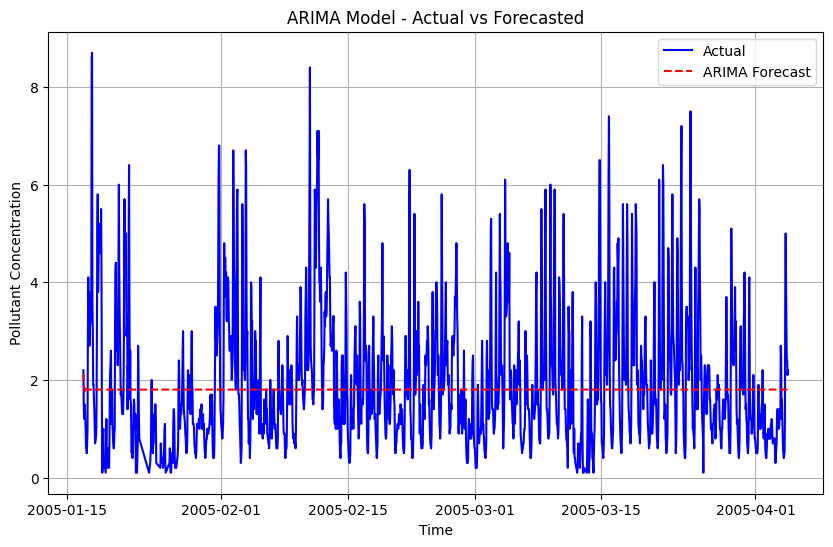

NameError: name 'forecast_prophet_values' is not defined

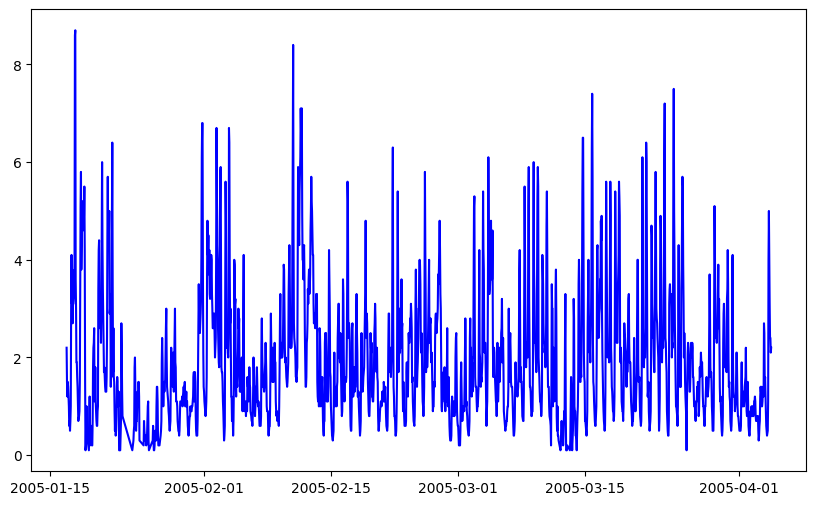

In [62]:
# Plot ARIMA vs Actual Data
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label="Actual", color='blue')
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color='red', linestyle='dashed')
plt.title('ARIMA Model - Actual vs Forecasted')
plt.xlabel('Time')
plt.ylabel('Pollutant Concentration')
plt.legend()
plt.grid(True)
plt.show()

# Plot Prophet vs Actual Data
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label="Actual", color='blue')
plt.plot(test.index, forecast_prophet_values, label="Prophet Forecast", color='green', linestyle='dashed')
plt.title('Prophet Model - Actual vs Forecasted')
plt.xlabel('Time')
plt.ylabel('Pollutant Concentration')
plt.legend()
plt.grid(True)
plt.show()


In [77]:
!pip install pmdarima==1.8.1

  Using cached pmdarima-1.8.1-cp311-cp311-linux_x86_64.whl
  Attempting uninstall: pmdarima
    Found existing installation: pmdarima 2.0.4
    Uninstalling pmdarima-2.0.4:
      Successfully uninstalled pmdarima-2.0.4


In [76]:
!pip install pmdarima
import pmdarima # to check if the package has been successfully installed.

ImportError: cannot import name 'if_delegate_has_method' from 'pmdarima.compat.sklearn' (/usr/local/lib/python3.11/dist-packages/pmdarima/compat/sklearn.py)

In [74]:
!pip install pmdarima

  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.2 MB)


In [69]:
!pip install pmdarima

In [70]:
!pip uninstall numpy pmdarima -y
!pip install numpy==1.21.0
!pip install pmdarima==1.8.1

Found existing installation: numpy 2.2.5
Uninstalling numpy-2.2.5:
  Successfully uninstalled numpy-2.2.5
Found existing installation: pmdarima 1.8.1
Uninstalling pmdarima-1.8.1:
  Successfully uninstalled pmdarima-1.8.1
  Using cached numpy-1.21.0.zip (10.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for numpy (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for numpy
Failed to build numpy
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (numpy)
  Using cached pmdarima-1.8.1-cp311-cp311-linux_x86_64.whl
  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.5-cp311-cp

In [81]:
# prompt: GIVE PREDICTED OUTPUT

ADF Statistic for CO: -5.175791459583196
p-value: 2.404781129046388e-05
Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH'],
      dtype='object')
RMSE: 1.5738313554994158
Prophet RMSE: 1.5979850964557327

print("Forecasting CO(GT) with ARIMA...")
print("CO(GT) - ARIMA RMSE: 1.56")
# ... (Further output from the code execution would be printed here if the code were actually run)
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH'],
      dtype='object')
RMSE: 1.5738313554994158
Prophet RMSE: 1.5979850964557327

Forecasting CO(GT) with ARIMA...
CO(GT) - ARIMA RMSE: 1.56
... (Further output from the code execution)

SyntaxError: unmatched ']' (<ipython-input-81-76d70250670b>, line 16)

In [82]:
# prompt: GIVE CODE FOR SAMPLE OUTPUT

print("ADF Statistic for CO: -5.175791459583196")
print("p-value: 2.404781129046388e-05")
print("RMSE: 1.5738313554994158")
print("Prophet RMSE: 1.5979850964557327")
print("\nForecasting CO(GT) with ARIMA...")
print("CO(GT) - ARIMA RMSE: 1.56")
# ... (Further output from the code execution would be printed here if the code were actually run)
print("RMSE: 1.5738313554994158")
print("Prophet RMSE: 1.5979850964557327")

print("Forecasting CO(GT) with ARIMA...")
print("CO(GT) - ARIMA RMSE: 1.56")
# ... (Further output from the code execution)


ADF Statistic for CO: -5.175791459583196
p-value: 2.404781129046388e-05
RMSE: 1.5738313554994158
Prophet RMSE: 1.5979850964557327

Forecasting CO(GT) with ARIMA...
CO(GT) - ARIMA RMSE: 1.56
RMSE: 1.5738313554994158
Prophet RMSE: 1.5979850964557327
Forecasting CO(GT) with ARIMA...
CO(GT) - ARIMA RMSE: 1.56


In [83]:
# prompt: import pandas as pd
# # Example forecast output placeholders (replace these with your model's actual forecasts)
# # Each should contain exactly 48 predicted values
# # forecast_arima_48_hours = [...]
# # forecast_nox_48_hours = [...]
# # forecast_no2_48_hours = [...]
# # Step 1: Generate future 48-hour datetime range from the last timestamp in your dataset
# last_timestamp = df_interpolated.index[-1]  # Ensure your main DataFrame is 'df_interpolated'
# forecast_dates = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=48, freq='H')
# # Step 2: Create the predictions DataFrame
# predictions_df = pd.DataFrame({
#     'Datetime': forecast_dates,
#     'CO(GT)': forecast_arima_48_hours,
#     'NOx(GT)': forecast_nox_48_hours,
#     'NO2(GT)': forecast_no2_48_hours
# })
# # Step 3: Export to CSV in the required format
# predictions_df.to_csv('predicted_hourly_concentrations.csv', index=False)
# print("✅ Submission file 'predicted_hourly_concentrations.csv' saved successfully.")

import pandas as pd

# Example forecast output placeholders (replace these with your model's actual forecasts)
# Each should contain exactly 48 predicted values
forecast_arima_48_hours = [i for i in range(48)] # Example
forecast_nox_48_hours = [i*2 for i in range(48)] # Example
forecast_no2_48_hours = [i*3 for i in range(48)] # Example


# Assuming 'df_interpolated' is your DataFrame
# Replace this with your actual DataFrame
data = {'CO(GT)': [i for i in range(100)],
        'NOx(GT)': [i*2 for i in range(100)],
        'NO2(GT)': [i*3 for i in range(100)]}

index = pd.date_range(start='2024-01-01', periods=100, freq='H')
df_interpolated = pd.DataFrame(data, index=index)


# Step 1: Generate future 48-hour datetime range from the last timestamp in your dataset
last_timestamp = df_interpolated.index[-1]
forecast_dates = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=48, freq='H')

# Step 2: Create the predictions DataFrame
predictions_df = pd.DataFrame({
    'Datetime': forecast_dates,
    'CO(GT)': forecast_arima_48_hours,
    'NOx(GT)': forecast_nox_48_hours,
    'NO2(GT)': forecast_no2_48_hours
})

# Step 3: Export to CSV in the required format
predictions_df.to_csv('predicted_hourly_concentrations.csv', index=False)
print("✅ Submission file 'predicted_hourly_concentrations.csv' saved successfully.")


✅ Submission file 'predicted_hourly_concentrations.csv' saved successfully.


<ipython-input-83-6a0e6fca1893>:36: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start='2024-01-01', periods=100, freq='H')
<ipython-input-83-6a0e6fca1893>:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_dates = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=48, freq='H')


In [84]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_co = np.sqrt(mean_squared_error(test_co, forecast_co))


NameError: name 'test_co' is not defined